# Task 4: House Price Prediction

## Objective
Predict house prices using regression, based on the Housing Prices dataset (Kaggle) containing 545 records with features such as area, bedrooms, bathrooms, stories, parking, and amenities (air conditioning, hot water heating, furnishing status, etc.).

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Housing.csv')

print(df.shape)
df.head()

(545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## Data Overview

Checking data types and missing values before proceeding.

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


## Exploratory Data Analysis

Examining the distribution of house prices and how numeric features relate to price.

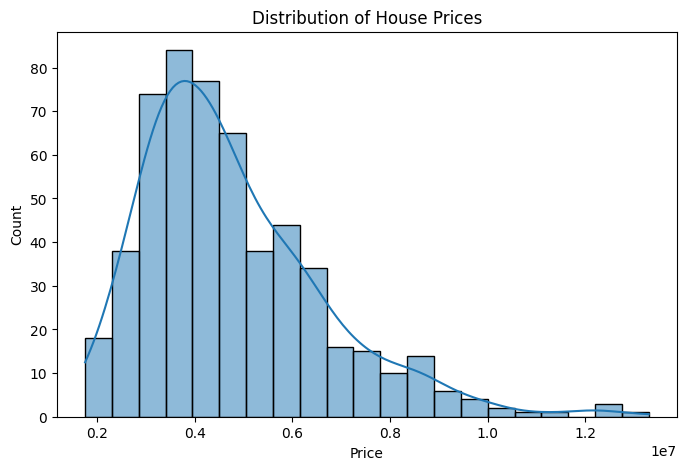

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], kde=True)
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.show()

The price distribution is right-skewed, with most houses priced between 3-5 million and a long tail of higher-priced properties extending up to ~13 million.

### Correlation Between Numeric Features and Price

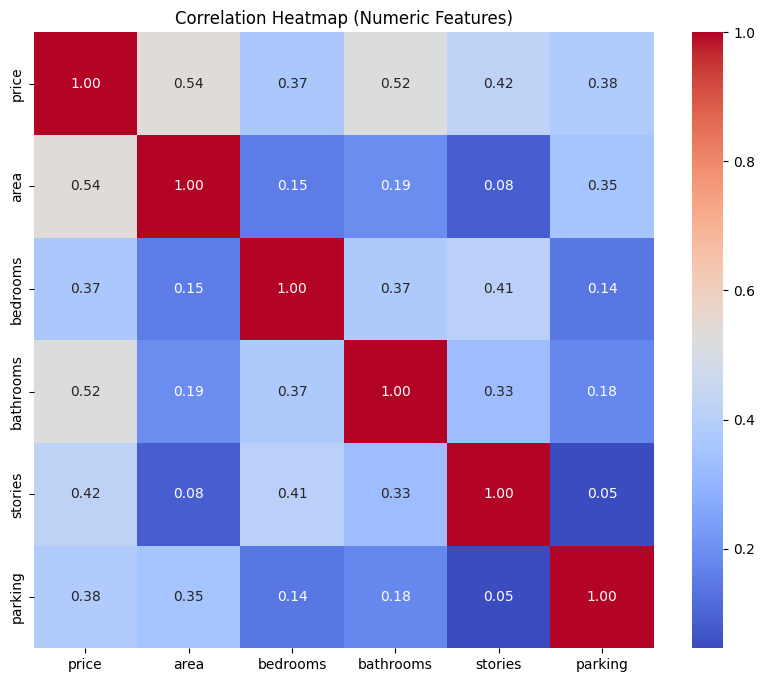

In [10]:
plt.figure(figsize=(10,8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (Numeric Features)')
plt.show()

Area (0.54) and bathrooms (0.52) show the strongest correlation with price, followed by stories (0.42), parking (0.38), and bedrooms (0.37). None of the numeric features are highly correlated with each other, so multicollinearity isn't a major concern.

## Encoding Categorical Features

Converting yes/no columns to binary (1/0) and one-hot encoding `furnishingstatus` so the data is ready for modeling.

In [12]:
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


## Train/Test Split

Splitting the data into features (X) and target (y), then into training and test sets (80/20 split).

In [13]:
from sklearn.model_selection import train_test_split

X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (436, 13)
Test set: (109, 13)


## Model Training

Training a Linear Regression model as the baseline for predicting house prices.

In [15]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Model trained successfully.")

Model trained successfully.


## Model Evaluation

Evaluating performance using RMSE, MAE, and R² score on the test set.

In [16]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:,.2f}")
print(f"MAE: {mae:,.2f}")
print(f"R² Score: {r2:.4f}")

RMSE: 1,324,506.96
MAE: 970,043.40
R² Score: 0.6529


### Actual vs Predicted Prices

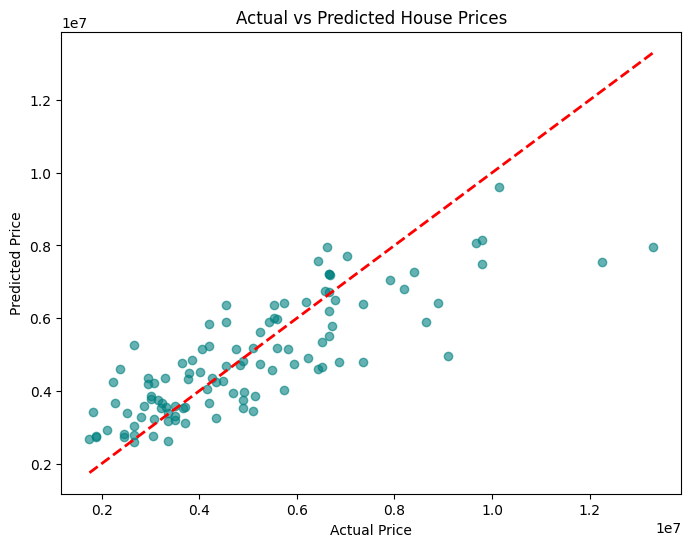

In [17]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Prices')
plt.show()

### Feature Coefficients

In [18]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

coefficients

,Feature,Coefficient
2,bathrooms,1.094445e+06
8,airconditioning,7.914267e+05
7,hotwaterheating,6.846499e+05
10,prefarea,6.298906e+05
3,stories,4.074766e+05
6,basement,3.902512e+05
4,mainroad,3.679199e+05
5,guestroom,2.316100e+05
9,parking,2.248419e+05
1,bedrooms,7.677870e+04


## Conclusions

- Trained a Linear Regression model to predict house prices using 12 features (area, bedrooms, bathrooms, stories, parking, amenities, and furnishing status).
- The model achieved an R² score of 0.65, meaning it explains about 65% of the variance in house prices, with RMSE of ~1,324,507 and MAE of ~970,043.
- Area and bathrooms showed the strongest correlation with price during EDA, consistent with their influence in the trained model.
- The model performs reasonably well for mid-range priced homes but tends to underpredict higher-priced properties, suggesting the relationship may not be purely linear at the top end — a tree-based model (e.g. Random Forest) could likely capture this better in future iterations.